In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
file_path = r'C:\Users\DELL\OneDrive\Desktop\New folder\titanic.csv'
df = pd.read_csv(file_path)
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
df.duplicated().value_counts()

False    891
Name: count, dtype: int64

In [ ]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
missing = df.isnull().sum()

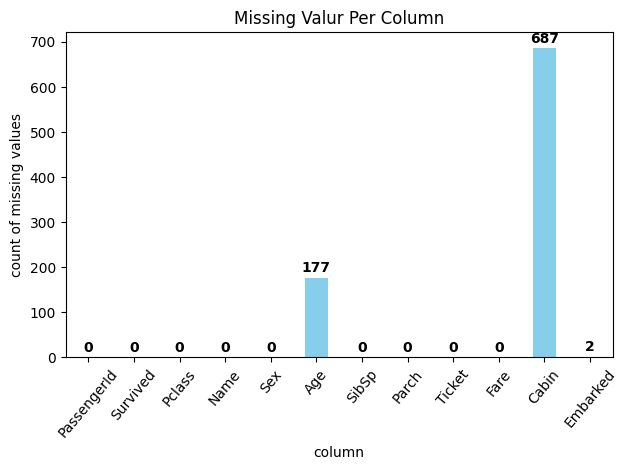

In [ ]:
ax=missing.plot(kind='bar',color='skyblue')
plt.title('Missing Valur Per Column')
plt.ylabel('count of missing values')
plt.xlabel('column')
plt.xticks(rotation=50)
for index,value in enumerate(missing):
    plt.text(index,value+5,str(value),ha='center',va='bottom',fontsize=10,fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
df = df.drop(columns=['Cabin'])


In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode())

In [ ]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [ ]:
survival_counts = df['Survived'].value_counts()
print("Survival counts:\n", survival_counts)

Survival counts:
 Survived
0    549
1    342
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_9036\3599535381.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived',data=df,palette='pastel')


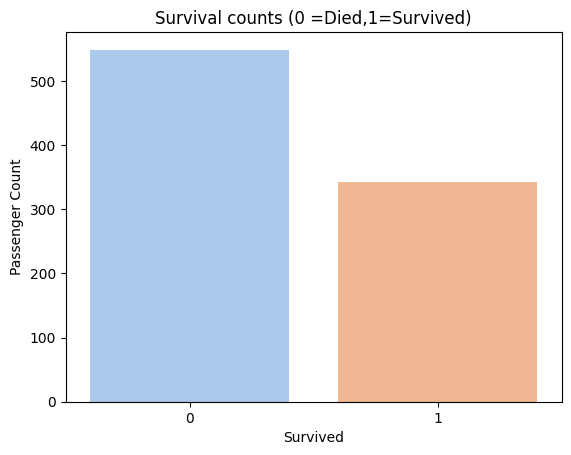

In [ ]:
sns.countplot(x='Survived',data=df,palette='pastel')
plt.title('Survival counts (0 =Died,1=Survived)')
plt.xlabel('Survived')
plt.ylabel('Passenger Count')
plt.show()

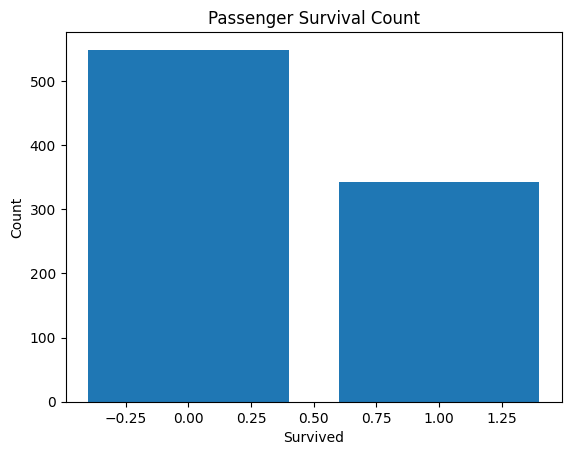

In [ ]:
counts=df['Survived'].value_counts()
plt.bar(counts.index,counts.values)
plt.xlabel("Survived")
plt.ylabel("Count")
plt.title("Passenger Survival Count")
plt.show()


In [ ]:
gender_counts=df['Sex'].value_counts()
print("\nGender Counts:\n",gender_counts)


Gender Counts:
 Sex
male      577
female    314
Name: count, dtype: int64


In [ ]:
survival_by_gender = df.groupby(['Sex','Survived']).size()
print("\nSurvival by gender:\n",survival_by_gender)


Survival by gender:
 Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
dtype: int64


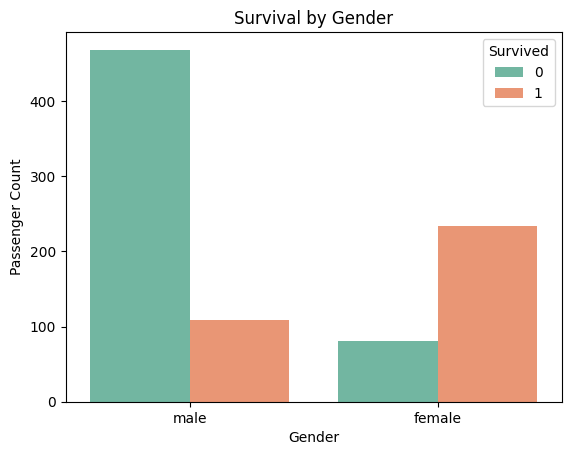

In [ ]:
sns.countplot(x='Sex',hue='Survived',data=df,palette='Set2')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.legend(title='Survived')
plt.show()

In [ ]:
pclass_counts=df['Pclass'].value_counts()
print("\nPassenger class Counts:\n",pclass_counts)



Passenger class Counts:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64


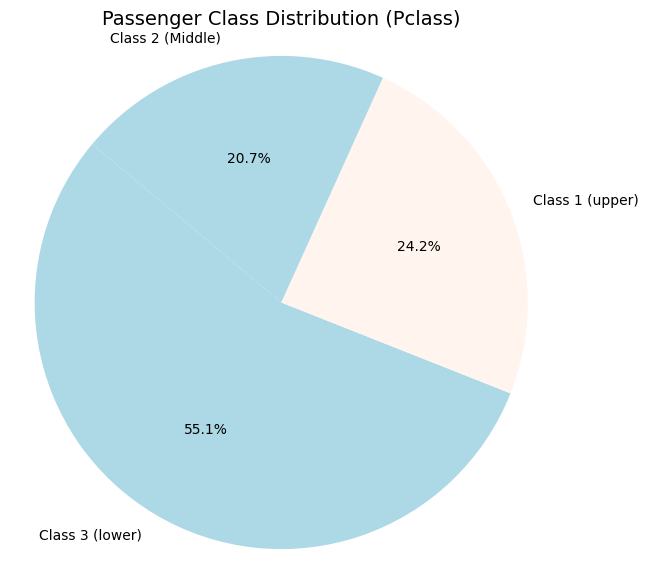

In [ ]:
labels=['Class 3 (lower)','Class 1 (upper)','Class 2 (Middle)']

plt.figure(figsize=(7,7))
plt.pie(pclass_counts,labels=labels,autopct='%1.1f%%', startangle=140, colors=['lightblue', 'seashell'])
plt.title('Passenger Class Distribution (Pclass)', fontsize=14)
plt.axis('equal')
plt.show()

In [ ]:
sns.kdeplot(df['Age'],fill=True,color='skyblue')
plt.title('Age Distribution (KDE Plot)')
plt.xlabel('Age')
plt.ylabel('Density')


In [ ]:
sns.kdeplot(df['Age'],fill=True,color='skyblue')
plt.title('Age Distribution (KDE Plot)')
plt.xlabel('Age')
plt.ylabel('Density')